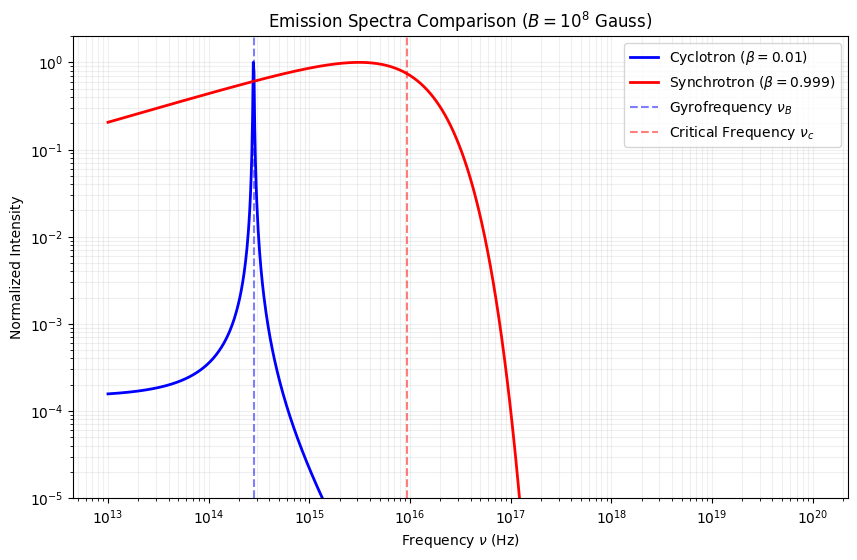

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants (CGS) ---
B = 1e8            # 10^8 Gauss
me = 9.11e-28      # Electron mass
e = 4.8e-10        # Electron charge
c = 3e10           # Speed of light

# --- Frequencies ---
def get_nu_B(gamma):
    return (e * B) / (2 * np.pi * gamma * me * c)

# Case 1: Cyclotron (v = 0.01c)
gamma1 = 1 / np.sqrt(1 - 0.01**2)
nu_B1 = get_nu_B(gamma1)

# Case 2: Synchrotron (v = 0.999c)
gamma2 = 1 / np.sqrt(1 - 0.999**2)
nu_B2 = get_nu_B(gamma2)
nu_c = 1.5 * (gamma2**2) * nu_B2  # Critical frequency

# --- Frequency Range for Plotting ---
nu = np.logspace(13, 20, 1000)

# 1. Cyclotron Model (Sharp Lorentzian Peak)
I_cyclotron = 1 / ((nu - nu_B1)**2 + (0.01*nu_B1)**2)

# 2. Synchrotron Model (F(x) approximation)
x = nu / nu_c
I_sync = x**(1/3) * np.exp(-x)

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.loglog(nu, I_cyclotron / np.max(I_cyclotron), label=r'Cyclotron ($\beta=0.01$)', color='blue', lw=2)
plt.loglog(nu, I_sync / np.max(I_sync), label=r'Synchrotron ($\beta=0.999$)', color='red', lw=2)

plt.axvline(nu_B1, color='blue', linestyle='--', alpha=0.5, label=r'Gyrofrequency $\nu_B$')
plt.axvline(nu_c, color='red', linestyle='--', alpha=0.5, label=r'Critical Frequency $\nu_c$')

plt.title(f'Emission Spectra Comparison ($B = 10^8$ Gauss)')
plt.xlabel('Frequency $\\nu$ (Hz)')
plt.ylabel('Normalized Intensity')
plt.ylim(1e-5, 2)
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.show()